In [1]:
file_path='/content/drive/MyDrive/Thiranex/Task-1/Online Retail.xlsx'

In [2]:
import pandas as pd
file_path='/content/drive/MyDrive/Thiranex/Task-1/Online Retail.xlsx'
df=pd.read_excel(file_path)
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [4]:
df.describe(include="all")

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909.0,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900.0,4070,4223,NaN,NaN,NaN,NaN,38
top,573585.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,1114.0,2313,2369,NaN,NaN,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570,NaN
min,NaN,NaN,NaN,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,2011-03-28 11:34:00,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,2011-07-19 17:17:00,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,2011-10-19 11:27:00,4.130000,16791.000000,NaN
max,NaN,NaN,NaN,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,NaN


In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 541909
Columns: 8


In [6]:
missing = df.isnull().sum()
print(missing)
print("Total missing values:", df.isnull().sum().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
Total missing values: 136534


In [7]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 5268


In [8]:
df = df.drop_duplicates()

print("Rows after removing duplicates:", df.shape[0])

Rows after removing duplicates: 536641


In [9]:
df[df["Description"].isnull()].head(10)
df[df["Description"].isnull()][["Quantity", "UnitPrice", "CustomerID", "Country"]].describe()

,Quantity,UnitPrice,CustomerID
count,1454.000000,1454.0,0.0
mean,-9.359697,0.0,NaN
std,243.238758,0.0,NaN
min,-3667.000000,0.0,NaN
25%,-24.000000,0.0,NaN
50%,-3.000000,0.0,NaN
75%,4.000000,0.0,NaN
max,5568.000000,0.0,NaN


In [10]:
# Handle missing values
df["Description"] = df["Description"].fillna("Unknown")
df["CustomerID"] = df["CustomerID"].astype("string")
df["CustomerID"] = df["CustomerID"].fillna("Unknown")
print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [11]:
print("Negative quantities:", (df["Quantity"] < 0).sum())
print("Zero/negative prices:", (df["UnitPrice"] <= 0).sum())
print("Maximum quantity:", df["Quantity"].max())
print("Maximum unit price:", df["UnitPrice"].max())

Negative quantities: 10587
Zero/negative prices: 2512
Maximum quantity: 80995
Maximum unit price: 38970.0


In [12]:
# Check negative quantities and invalid prices
print("Negative quantities:", (df["Quantity"] < 0).sum())
print("Zero/negative prices:", (df["UnitPrice"] <= 0).sum())
print("Maximum quantity:", df["Quantity"].max())
print("Maximum unit price:", df["UnitPrice"].max())
# Remove invalid sales transactions
df = df[df["Quantity"] > 0]
df = df[df["UnitPrice"] > 0]

print("Rows after removing invalid transactions:", len(df))

Negative quantities: 10587
Zero/negative prices: 2512
Maximum quantity: 80995
Maximum unit price: 38970.0
Rows after removing invalid transactions: 524878


In [13]:
df["Sales"] = df["Quantity"] * df["UnitPrice"]
df.head()
print(df[["Quantity", "UnitPrice", "Sales"]].describe())

            Quantity      UnitPrice          Sales
count  524878.000000  524878.000000  524878.000000
mean       10.616600       3.922573      20.275399
std       156.280031      36.093028     271.693566
min         1.000000       0.001000       0.001000
25%         1.000000       1.250000       3.900000
50%         4.000000       2.080000       9.920000
75%        11.000000       4.130000      17.700000
max     80995.000000   13541.330000  168469.600000


In [14]:
# IQR method for Quantity
Q1_quantity = df["Quantity"].quantile(0.25)
Q3_quantity = df["Quantity"].quantile(0.75)
IQR_quantity = Q3_quantity - Q1_quantity
upper_quantity = Q3_quantity + 1.5 * IQR_quantity
# IQR method for UnitPrice
Q1_price = df["UnitPrice"].quantile(0.25)
Q3_price = df["UnitPrice"].quantile(0.75)
IQR_price = Q3_price - Q1_price
upper_price = Q3_price + 1.5 * IQR_price
print("Quantity upper limit:", upper_quantity)
print("UnitPrice upper limit:", upper_price)
quantity_outliers = df[df["Quantity"] > upper_quantity]
price_outliers = df[df["UnitPrice"] > upper_price]
print("Quantity outliers:", len(quantity_outliers))
print("UnitPrice outliers:", len(price_outliers))

Quantity upper limit: 26.0
UnitPrice upper limit: 8.45
Quantity outliers: 27111
UnitPrice outliers: 37827


In [15]:
# Cap outliers using IQR upper limits

df["Quantity"] = df["Quantity"].clip(upper=upper_quantity)
df["UnitPrice"] = df["UnitPrice"].clip(upper=upper_price)

# Recalculate Sales after handling outliers
df["Sales"] = df["Quantity"] * df["UnitPrice"]

print(df[["Quantity", "UnitPrice", "Sales"]].describe())

            Quantity      UnitPrice          Sales
count  524878.000000  524878.000000  524878.000000
mean        6.922186       2.962309      13.683006
std         7.566009       2.397184      17.386715
min         1.000000       0.001000       0.001000
25%         1.000000       1.250000       3.900000
50%         4.000000       2.080000       8.450000
75%        11.000000       4.130000      16.900000
max        26.000000       8.450000     219.700000


In [16]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Rows: 524878
Columns: 9

Missing values:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
Sales          0
dtype: int64

Duplicate rows: 33


In [17]:
# Remove duplicates created after outlier handling
df = df.drop_duplicates()

print("Final rows:", df.shape[0])
print("Final columns:", df.shape[1])
print("Final duplicate rows:", df.duplicated().sum())

Final rows: 524845
Final columns: 9
Final duplicate rows: 0


In [18]:
print("Missing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

Missing values:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
Sales          0
dtype: int64

Data types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID     string[python]
Country                object
Sales                 float64
dtype: object


In [19]:
df["Sales"] = pd.to_numeric(df["Sales"], errors="coerce")
print(df.dtypes)
print(df["Sales"].isnull().sum())

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID     string[python]
Country                object
Sales                 float64
dtype: object
0


In [20]:
# Basic KPIs

total_sales = df["Sales"].sum()
total_orders = df["InvoiceNo"].nunique()
total_products = df["StockCode"].nunique()
total_customers = df["CustomerID"].nunique()
total_countries = df["Country"].nunique()

print("Total Sales:", round(total_sales, 2))
print("Total Orders:", total_orders)
print("Total Products:", total_products)
print("Total Customers:", total_customers)
print("Total Countries:", total_countries)

Total Sales: 7181282.41
Total Orders: 19960
Total Products: 3922
Total Customers: 4339
Total Countries: 38


In [21]:
country_sales = (
    df.groupby("Country")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

print(country_sales.head(10))

Country
United Kingdom    6173370.454
Germany            187834.430
EIRE               179751.510
France             162395.640
Netherlands         90528.750
Australia           47639.360
Switzerland         45047.560
Spain               42484.810
Belgium             36111.110
Norway              27253.560
Name: Sales, dtype: float64


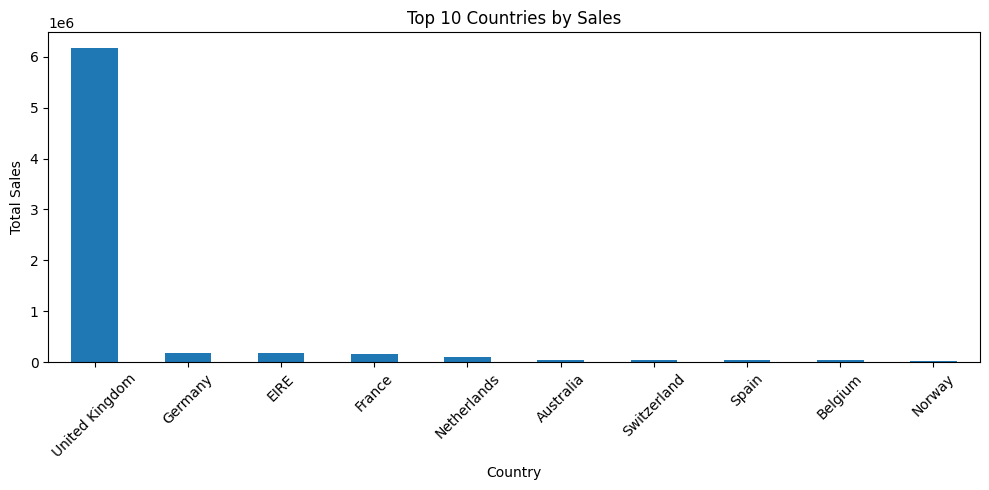

In [22]:
import matplotlib.pyplot as plt

country_sales.head(10).plot(kind="bar", figsize=(10, 5))

plt.title("Top 10 Countries by Sales")
plt.xlabel("Country")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

YearMonth
2010-12     562395.620
2011-01     431308.590
2011-02     373327.690
2011-03     494463.540
2011-04     383757.361
2011-05     540598.020
2011-06     488060.150
2011-07     493249.241
2011-08     503099.260
2011-09     730367.332
2011-10     793852.830
2011-11    1062365.740
2011-12     324437.040
Freq: M, Name: Sales, dtype: float64


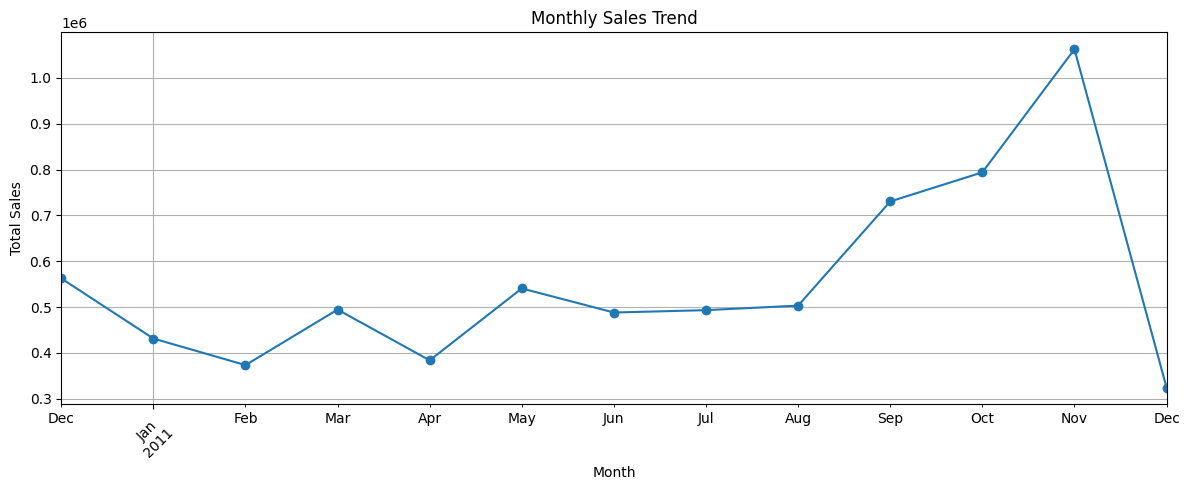

In [23]:
# Create Year-Month column
df["YearMonth"] = df["InvoiceDate"].dt.to_period("M")

# Calculate monthly sales
monthly_sales = (
    df.groupby("YearMonth")["Sales"]
    .sum()
)

print(monthly_sales)

plt.figure(figsize=(12, 5))

monthly_sales.plot(kind="line", marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

Description
REGENCY CAKESTAND 3 TIER              93034.80
PARTY BUNTING                         64157.76
WHITE HANGING HEART T-LIGHT HOLDER    60604.10
JUMBO BAG RED RETROSPOT               46417.86
PAPER CHAIN KIT 50'S CHRISTMAS        36210.04
ASSORTED COLOUR BIRD ORNAMENT         35690.25
SPOTTY BUNTING                        33314.05
CHILLI LIGHTS                         32126.28
JAM MAKING SET WITH JARS              30359.99
SET OF 3 CAKE TINS PANTRY DESIGN      28078.15
Name: Sales, dtype: float64


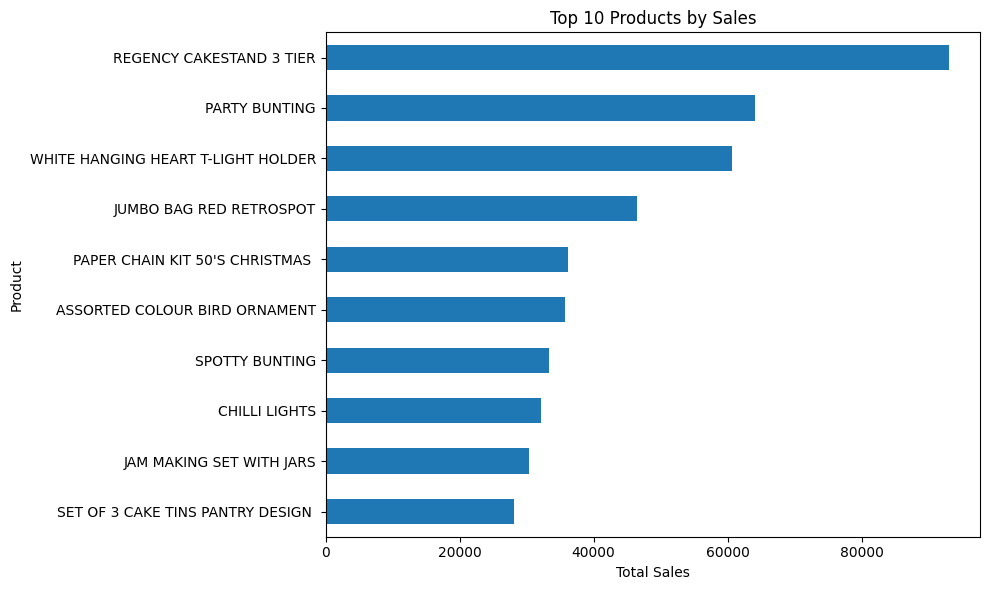

In [24]:
top_products = (
    df.groupby("Description")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_products)
plt.figure(figsize=(10, 6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

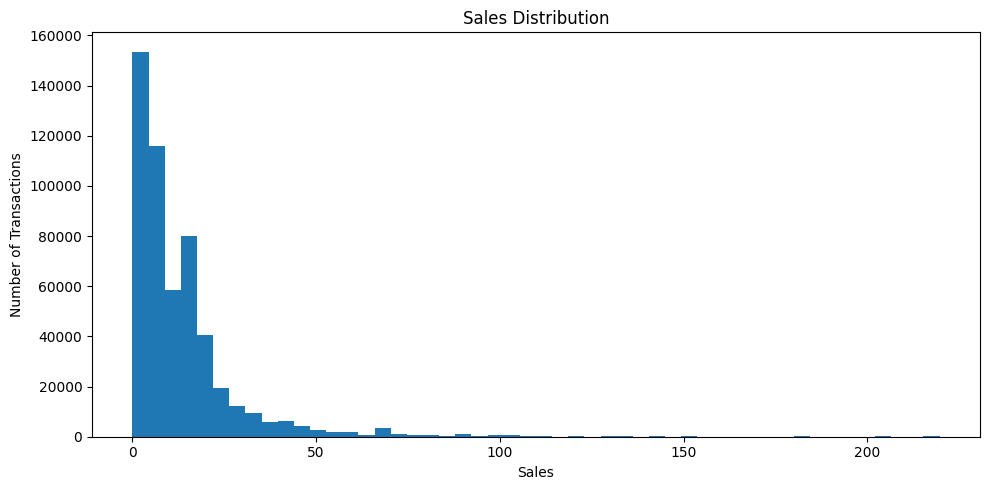

In [25]:
plt.figure(figsize=(10, 5))

plt.hist(df["Sales"], bins=50)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

In [26]:
country_sales_pct = (country_sales / country_sales.sum() * 100).head(10)

print(country_sales_pct)

Country
United Kingdom    85.964736
Germany            2.615611
EIRE               2.503056
France             2.261374
Netherlands        1.260621
Australia          0.663382
Switzerland        0.627291
Spain              0.591605
Belgium            0.502850
Norway             0.379508
Name: Sales, dtype: float64


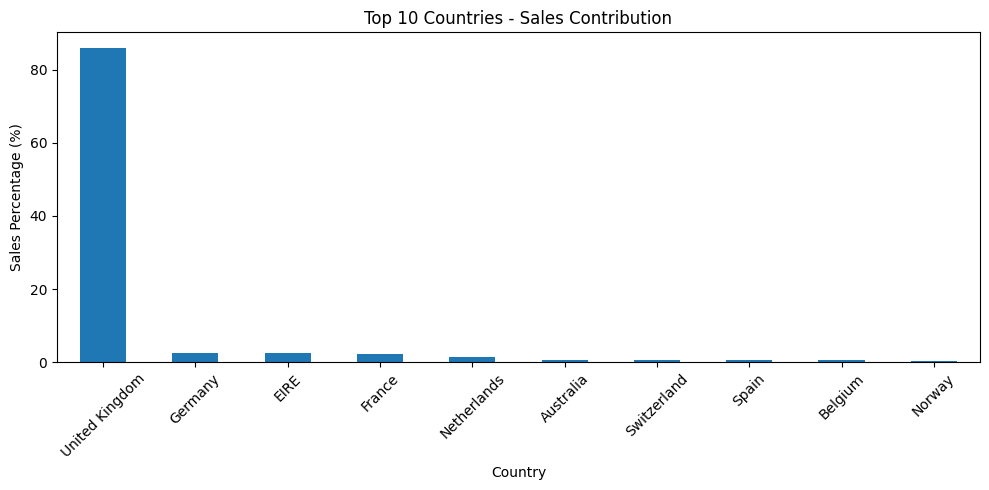

In [27]:
plt.figure(figsize=(10, 5))

country_sales_pct.plot(kind="bar")

plt.title("Top 10 Countries - Sales Contribution")
plt.xlabel("Country")
plt.ylabel("Sales Percentage (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [28]:
correlation = df[["Quantity", "UnitPrice", "Sales"]].corr()

print(correlation)

           Quantity  UnitPrice     Sales
Quantity   1.000000  -0.376126  0.523780
UnitPrice -0.376126   1.000000  0.238714
Sales      0.523780   0.238714  1.000000


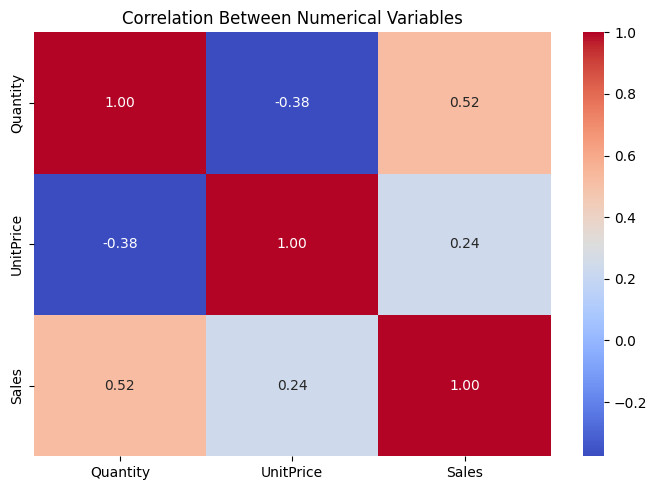

In [29]:
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Between Numerical Variables")
plt.tight_layout()
plt.show()

In [30]:
# Save cleaned dataset
output_path = "/content/drive/MyDrive/Thiranex/Task-1/cleaned_online_retail.csv"

df.to_csv(output_path, index=False)

print("Cleaned dataset saved successfully!")
print(output_path)

Cleaned dataset saved successfully!
/content/drive/MyDrive/Thiranex/Task-1/cleaned_online_retail.csv
